In [1]:
import hashlib
import json
import math
import random
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from torch.utils.data import DataLoader, Dataset, Sampler
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

In [2]:
try:
    import open_clip
    from huggingface_hub import hf_hub_download
except ImportError:
    !pip install -q open_clip_torch huggingface_hub
    import open_clip
    from huggingface_hub import hf_hub_download

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 63.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.8 MB/s eta 0:00:00


In [3]:
SEED = 42
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

INPUT_ROOT = Path('/kaggle/input')
WORK_DIR = Path('/kaggle/working')

DATASET_CANDIDATES = [
    INPUT_ROOT / 'datasets/edwardsx/geovision-tiles-sit2',
    INPUT_ROOT / 'geovision-tiles-sit2',
]
DATASET_DIR = next((p for p in DATASET_CANDIDATES if p.exists()), DATASET_CANDIDATES[-1])

OUT_DIR = WORK_DIR / 'sit2_7_clip_sae_1500tiles'
CKPT_DIR = OUT_DIR / 'checkpoints'
FIG_DIR = OUT_DIR / 'figures'
EMB_DIR = OUT_DIR / 'embeddings'
for path in [OUT_DIR, CKPT_DIR, FIG_DIR, EMB_DIR]:
    path.mkdir(parents=True, exist_ok=True)

TILES_PATH = DATASET_DIR / 'tiles_train.npz'
META_PATH = DATASET_DIR / 'tiles_meta.parquet'

BAND_NAMES = ['B1','B2','B3','B4','B5','B6','B7','B8','B8A','B9','B11','B12','SCL']
OPTICAL_BANDS = list(range(12))
OPTICAL_NAMES = BAND_NAMES[:12]
CLASES = ['contaminacion_alta_NO2', 'contaminacion_alta_SO2', 'ozono_anomalo', 'vegetacion_densa', 'suelo_urbano']
CLASE_TO_IDX = {c: i for i, c in enumerate(CLASES)}

REMOTECLIP_REPO = 'chendelong/RemoteCLIP'
REMOTECLIP_FILE = 'RemoteCLIP-ViT-B-32.pt'

# *** NUEVO: subset de 1500 tiles (300 por clase) ***
TILES_PER_CLASS = 300
N_TILES_TOTAL = TILES_PER_CLASS * len(CLASES)

BATCH_SIZE = 60
GRAD_ACCUM_STEPS = 2
NUM_WORKERS = 0
PHASE1_EPOCHS = 12
PHASE2_EPOCHS = 10
EPOCHS = PHASE1_EPOCHS + PHASE2_EPOCHS
PATIENCE = 6
LR_BACKBONE = 1e-5
LR_HEADS = 3e-4
LR_SAE = 1e-3
WEIGHT_DECAY = 0.2
LORA_RANK = 16
IMAGE_SIZE = 224

ALPHA_SAE = 0.05
LAMBDA_L1 = 3e-2   # *** REDUCIDO de 5e-2 a 3e-2 ***
SAE_DIM = 1024
PROJ_DIM = 256
SAE_DEAD_RESAMPLE_EVERY = 4
SAE_DEAD_THRESHOLD = 1e-3

BETA_CLASS_INIT = 0.30
BETA_CLASS_FLOOR = 0.05
PER_CLASS_PER_BATCH = 12
HARD_WEIGHT_MAX = 3.0

MIN_UNIQUE_CAPTION_RATIO = 0.85
N_QUANTILES = 8
QUANTILE_LABELS = list('ABCDEFGH')

PDF_THRESHOLDS = {
    'recall_at_1_min': 0.45,
    'recall_at_5_min': 0.70,
    'sparsity_visual_min': 0.70,
    'recon_visual_max': 0.05,
}

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True

print('DEVICE:', DEVICE)
print('DATASET_DIR:', DATASET_DIR)
print('OUT_DIR:', OUT_DIR)
print(f'Subset: {N_TILES_TOTAL} tiles ({TILES_PER_CLASS} por clase x {len(CLASES)} clases)')
print('Effective batch:', BATCH_SIZE * GRAD_ACCUM_STEPS, 'phase1:', PHASE1_EPOCHS, 'phase2:', PHASE2_EPOCHS)

DEVICE: cuda
DATASET_DIR: /kaggle/input/datasets/edwardsx/geovision-tiles-sit2
OUT_DIR: /kaggle/working/sit2_7_clip_sae_1500tiles
Subset: 1500 tiles (300 por clase x 5 clases)
Effective batch: 120 phase1: 12 phase2: 10


In [4]:
data = np.load(TILES_PATH, allow_pickle=False)
if 'tiles' in data.files:
    tiles_full = data['tiles']
elif 'data' in data.files:
    tiles_full = data['data']
else:
    tiles_full = data[data.files[0]]

meta_full = pd.read_parquet(META_PATH).reset_index(drop=True)
print(f'Full dataset: tiles={tiles_full.shape} meta={meta_full.shape}')
print(meta_full['clase'].value_counts().sort_index())

# Subsample estratificado: TILES_PER_CLASS por clase, con seed reproducible
rng_sub = np.random.RandomState(SEED)
selected_idx = []
for clase in CLASES:
    pool = np.where(meta_full['clase'].values == clase)[0]
    if len(pool) < TILES_PER_CLASS:
        raise ValueError(f'Clase {clase} solo tiene {len(pool)} tiles, no alcanza {TILES_PER_CLASS}')
    rng_sub.shuffle(pool)
    selected_idx.extend(pool[:TILES_PER_CLASS].tolist())
selected_idx = np.sort(np.array(selected_idx))

tiles = tiles_full[selected_idx]
meta = meta_full.iloc[selected_idx].reset_index(drop=True)
print(f'\nSubset: tiles={tiles.shape} meta={meta.shape}')
print(meta['clase'].value_counts().sort_index())
del tiles_full, meta_full

Full dataset: tiles=(5000, 13, 64, 64) meta=(5000, 22)
clase
contaminacion_alta_NO2    1000
contaminacion_alta_SO2    1000
ozono_anomalo             1000
suelo_urbano              1000
vegetacion_densa          1000
Name: count, dtype: int64

Subset: tiles=(1500, 13, 64, 64) meta=(1500, 22)
clase
contaminacion_alta_NO2    300
contaminacion_alta_SO2    300
ozono_anomalo             300
suelo_urbano              300
vegetacion_densa          300
Name: count, dtype: int64


In [5]:
indices = np.arange(len(meta))
train_idx, temp_idx = train_test_split(indices, train_size=0.70, random_state=SEED, stratify=meta['clase'])
val_idx, test_idx = train_test_split(temp_idx, test_size=0.50, random_state=SEED, stratify=meta.loc[temp_idx, 'clase'])

assert len(set(train_idx) & set(val_idx)) == 0
assert len(set(train_idx) & set(test_idx)) == 0
assert len(set(val_idx) & set(test_idx)) == 0

split_map = pd.Series(index=meta.index, dtype='object')
split_map.iloc[train_idx] = 'train'
split_map.iloc[val_idx] = 'val'
split_map.iloc[test_idx] = 'test'
meta['split_sit2_6'] = split_map
print(meta.groupby(['split_sit2_6', 'clase']).size().unstack(fill_value=0))
print('Train/Val/Test:', len(train_idx), len(val_idx), len(test_idx))

clase         contaminacion_alta_NO2  contaminacion_alta_SO2  ozono_anomalo  \
split_sit2_6                                                                  
test                              45                      45             45   
train                            210                     210            210   
val                               45                      45             45   

clase         suelo_urbano  vegetacion_densa  
split_sit2_6                                  
test                    45                45  
train                  210               210  
val                     45                45  
Train/Val/Test: 1050 225 225


In [6]:
train_tiles = tiles[train_idx][:, OPTICAL_BANDS].astype(np.float32)
band_mean = train_tiles.mean(axis=(0, 2, 3))
band_std = train_tiles.std(axis=(0, 2, 3)) + 1e-6
with open(OUT_DIR / 'normalization_train_only.json', 'w') as f:
    json.dump({'band_names': OPTICAL_NAMES, 'mean': band_mean.tolist(), 'std': band_std.tolist()}, f, indent=2)
print('Band mean:', np.round(band_mean, 2))
print('Band std:', np.round(band_std, 2))
del train_tiles

Band mean: [ 841.04  902.73 1082.01 1018.86 1394.54 2335.49 2736.92 2695.33 2943.95
 2923.68 2221.06 1612.11]
Band std: [ 797.65  868.88  815.86  874.99  797.29  759.3   906.03  931.42  960.44
 1052.53  820.93  955.56]


In [7]:
def safe_month(value):
    if pd.isna(value):
        return -1
    text = str(value)
    parsed = pd.to_datetime(text, errors='coerce')
    if pd.isna(parsed) and len(text) >= 8 and text[:8].isdigit():
        parsed = pd.to_datetime(text[:8], format='%Y%m%d', errors='coerce')
    if pd.isna(parsed):
        return -1
    return int(parsed.month)


def month_period(value):
    month = safe_month(value)
    if month in [12, 1, 2, 3]:
        return 'dry season'
    if month in [4, 5, 10, 11]:
        return 'rain transition season'
    if month in [6, 7, 8, 9]:
        return 'mid-year season'
    return 'unknown season'


def zone_label(lat, lon):
    if pd.isna(lat) or pd.isna(lon):
        return 'Cali metropolitan area'
    ns = 'north' if lat >= 3.45 else 'south'
    ew = 'east' if lon >= -76.50 else 'west'
    lat_band = 'upper' if lat >= 3.53 else 'central' if lat >= 3.40 else 'lower'
    lon_band = 'inner' if lon >= -76.45 else 'middle' if lon >= -76.55 else 'outer'
    return f'{lat_band}-{lon_band} {ns}-{ew} Cali zone'


def cell_hash(lat, lon):
    if pd.isna(lat) or pd.isna(lon):
        return 'cell_xxxx'
    key = f'{round(float(lat), 2):.2f}|{round(float(lon), 2):.2f}'
    h = hashlib.md5(key.encode('utf-8')).hexdigest()[:6]
    return f'cell_{h}'

In [8]:
def train_quantile_edges(series, train_idx, n=N_QUANTILES):
    values = series.iloc[train_idx].dropna().astype(float)
    if len(values) == 0:
        return [0.0] * (n - 1)
    qs = [i / n for i in range(1, n)]
    return values.quantile(qs).to_list()


def quantile_bin(value, edges, labels=None):
    if labels is None:
        labels = QUANTILE_LABELS
    if pd.isna(value):
        return labels[0]
    v = float(value)
    for edge, label in zip(edges, labels[:-1]):
        if v <= float(edge):
            return label
    return labels[-1]


BAND_INDEX = {name: i for i, name in enumerate(BAND_NAMES)}
for name in ['B2', 'B3', 'B4', 'B8', 'B11', 'B12']:
    arr = tiles[:, BAND_INDEX[name]].astype(np.float32)
    meta[f'{name}_mean_tile'] = arr.mean(axis=(1, 2))
    meta[f'{name}_std_tile'] = arr.std(axis=(1, 2))
meta['visible_mean_tile'] = meta[['B2_mean_tile', 'B3_mean_tile', 'B4_mean_tile']].mean(axis=1)
meta['nir_swir_contrast_tile'] = meta['B8_mean_tile'] - meta['B11_mean_tile']
meta['texture_mean_tile'] = meta[['B2_std_tile', 'B3_std_tile', 'B4_std_tile', 'B8_std_tile']].mean(axis=1)
meta['wind_speed_tile'] = np.sqrt(meta['era5_u10'].fillna(0) ** 2 + meta['era5_v10'].fillna(0) ** 2)

CAPTION_FEATURES = [
    'ndvi', 'ndbi', 'scl_pct', 'modis_AOD_047', 'modis_WV',
    'era5_BLH', 'era5_T2m', 'era5_RH850', 'wind_speed_tile',
    'visible_mean_tile', 'nir_swir_contrast_tile', 'texture_mean_tile',
    'B2_mean_tile', 'B3_mean_tile', 'B4_mean_tile', 'B8_mean_tile', 'B11_mean_tile', 'B12_mean_tile',
    'no2', 'so2', 'o3',
]
CAPTION_QUANTILES = {col: train_quantile_edges(meta[col], train_idx) for col in CAPTION_FEATURES}
with open(OUT_DIR / 'caption_quantiles_train_only.json', 'w') as f:
    json.dump(CAPTION_QUANTILES, f, indent=2)
print('Quantile edges sample (ndvi):', np.round(CAPTION_QUANTILES['ndvi'], 4))

Quantile edges sample (ndvi): [0.1711 0.2525 0.388  0.5126 0.6025 0.6578 0.7071]


In [9]:
def class_phrase(clase):
    phrases = {
        'contaminacion_alta_NO2': [
            'traffic-related nitrogen dioxide pattern',
            'urban combustion signature near mobility corridors',
            'anthropogenic NO2 pseudo-label over urban land',
            'nitrogen dioxide atmospheric category linked to built-up activity',
            'NO2-oriented pollution context in the Cali urban footprint',
        ],
        'contaminacion_alta_SO2': [
            'industrial sulfur dioxide pattern',
            'SO2 signal associated with combustion and industrial activity',
            'sulfur dioxide pseudo-label near regional emission corridors',
            'industrial atmospheric loading category',
            'SO2-oriented pollution context in the metropolitan corridor',
        ],
        'ozono_anomalo': [
            'photochemical ozone anomaly pattern',
            'regional O3 regime under atmospheric stability',
            'ozone pseudo-label linked to secondary pollutant formation',
            'diffuse high-ozone atmospheric category',
            'O3-oriented anomaly context over the Cali region',
        ],
        'vegetacion_densa': [
            'dense vegetation cover with strong near infrared response',
            'healthy canopy or cropland dominated tile',
            'green biomass surface with low urban influence',
            'vegetated land cover context in the metropolitan surroundings',
            'high vegetation semantic category in Sentinel-2 imagery',
        ],
        'suelo_urbano': [
            'urban built-up surface with sparse vegetation',
            'impervious city fabric with roads and buildings',
            'dense urban land cover with low vegetation response',
            'built environment context near populated areas',
            'urban surface semantic category in Sentinel-2 imagery',
        ],
    }
    return phrases[clase]


CLASS_PROMPTS = {c: class_phrase(c) for c in CLASES}


def compact_signature(row, cols):
    return ''.join(quantile_bin(row.get(col), CAPTION_QUANTILES[col]) for col in cols)


def make_captions(row, idx):
    zone = zone_label(row.get('lat'), row.get('lon'))
    period = month_period(row.get('time_s2'))
    cell = cell_hash(row.get('lat'), row.get('lon'))
    phrases = class_phrase(row['clase'])
    bins = {col: quantile_bin(row.get(col), CAPTION_QUANTILES[col]) for col in CAPTION_FEATURES}
    sig_pollution = compact_signature(row, ['no2', 'so2', 'o3', 'modis_AOD_047', 'era5_BLH'])
    sig_visual = compact_signature(row, ['ndvi', 'ndbi', 'visible_mean_tile', 'nir_swir_contrast_tile', 'texture_mean_tile'])
    sig_meteo = compact_signature(row, ['era5_T2m', 'era5_RH850', 'wind_speed_tile', 'modis_WV', 'scl_pct'])
    sig_bands = compact_signature(row, ['B2_mean_tile', 'B3_mean_tile', 'B4_mean_tile', 'B8_mean_tile', 'B11_mean_tile'])
    sig_full = compact_signature(row, ['ndvi', 'ndbi', 'modis_AOD_047', 'era5_BLH', 'visible_mean_tile', 'nir_swir_contrast_tile', 'texture_mean_tile', 'no2', 'so2', 'o3'])

    captions = [
        f'Sentinel-2 tile in {zone}, {period}. Visual signature {sig_visual}; atmospheric signature {sig_pollution}. NDVI {bins["ndvi"]}, NDBI {bins["ndbi"]}. Semantic class: {phrases[0]}.',
        f'Remote sensing scene at {cell} with band signature {sig_bands} and meteorological signature {sig_meteo}. Aerosol bin {bins["modis_AOD_047"]}, boundary layer bin {bins["era5_BLH"]}. Interpretation: {phrases[1]}.',
        f'Cali multispectral tile, compact code {sig_full}. Visible brightness bin {bins["visible_mean_tile"]}, NIR-SWIR contrast bin {bins["nir_swir_contrast_tile"]}, texture bin {bins["texture_mean_tile"]}. Context: {phrases[2]}.',
        f'GeoVision sample from {zone}. Atmospheric bins NO2={bins["no2"]}, SO2={bins["so2"]}, O3={bins["o3"]}; wind {bins["wind_speed_tile"]}; water vapor {bins["modis_WV"]}. Label meaning: {phrases[3]}.',
        f'High-uniqueness caption code {sig_visual}-{sig_pollution}-{sig_meteo} for a Sentinel-2 tile. Valid pixels bin {bins["scl_pct"]}, red band bin {bins["B4_mean_tile"]}, NIR band bin {bins["B8_mean_tile"]}. Scene: {phrases[4]}.',
    ]
    rs = np.random.RandomState(int(idx) % (2 ** 31 - 1))
    order = rs.permutation(len(captions))
    return [captions[k] for k in order]


caption_lists = [make_captions(meta.iloc[i], i) for i in range(len(meta))]
for j in range(5):
    meta[f'caption_{j}'] = [c[j] for c in caption_lists]
meta['texto_pdf_literal'] = meta['caption_0']

all_captions = [c for lst in caption_lists for c in lst]
text_stats = {
    'n_images': int(len(meta)),
    'captions_per_image': 5,
    'n_captions': int(len(all_captions)),
    'n_unique_captions': int(len(set(all_captions))),
    'unique_caption_ratio': float(len(set(all_captions)) / len(all_captions)),
    'unique_first_caption_ratio': float(meta['caption_0'].nunique() / len(meta)),
}
with open(OUT_DIR / 'text_stats.json', 'w') as f:
    json.dump(text_stats, f, indent=2)
print(json.dumps(text_stats, indent=2))
print(meta[['clase', 'caption_0']].head(3).to_string())
assert text_stats['unique_caption_ratio'] >= MIN_UNIQUE_CAPTION_RATIO, text_stats
assert all('e-05' not in c and 'e+0' not in c for c in all_captions[:200]), 'numerical S5P leak suspected'

{
  "n_images": 1500,
  "captions_per_image": 5,
  "n_captions": 7500,
  "n_unique_captions": 7057,
  "unique_caption_ratio": 0.9409333333333333,
  "unique_first_caption_ratio": 0.9833333333333333
}
                    clase                                                                                                                                                                     caption_0
0  contaminacion_alta_NO2  Cali multispectral tile, compact code GCAHBFBEAA. Visible brightness bin B, NIR-SWIR contrast bin F, texture bin B. Context: anthropogenic NO2 pseudo-label over urban land.
1  contaminacion_alta_NO2  Cali multispectral tile, compact code GDAHBECBAA. Visible brightness bin B, NIR-SWIR contrast bin E, texture bin C. Context: anthropogenic NO2 pseudo-label over urban land.
2  contaminacion_alta_NO2  Cali multispectral tile, compact code AGACGBGHAA. Visible brightness bin G, NIR-SWIR contrast bin B, texture bin G. Context: anthropogenic NO2 pseudo-label over urban land.


In [10]:
class TilesClipDataset(Dataset):
    def __init__(self, tiles, meta, indices, band_mean, band_std, train=False):
        self.tiles = tiles
        self.meta = meta.reset_index(drop=True)
        self.indices = np.asarray(indices)
        self.band_mean = torch.tensor(band_mean, dtype=torch.float32).view(12, 1, 1)
        self.band_std = torch.tensor(band_std, dtype=torch.float32).view(12, 1, 1)
        self.train = train

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, item):
        idx = int(self.indices[item])
        x = torch.tensor(self.tiles[idx, OPTICAL_BANDS].astype(np.float32))
        x = (x - self.band_mean) / self.band_std
        x = torch.clamp(x, -3.0, 3.0)
        if self.train:
            if torch.rand(()) < 0.5:
                x = torch.flip(x, dims=[2])
            k = int(torch.randint(0, 4, ()).item())
            x = torch.rot90(x, k, dims=[1, 2])
        x = F.interpolate(x.unsqueeze(0), size=(IMAGE_SIZE, IMAGE_SIZE), mode='bilinear', align_corners=False).squeeze(0)
        row = self.meta.loc[idx]
        captions = [row[f'caption_{j}'] for j in range(5)]
        text = random.choice(captions) if self.train else captions[0]
        label = row['clase']
        return {'image': x, 'text': text, 'captions': captions, 'label': label, 'label_idx': CLASE_TO_IDX[label], 'index': int(idx), 'pos': int(item)}


def collate_fn(batch):
    return {
        'image': torch.stack([b['image'] for b in batch]),
        'text': [b['text'] for b in batch],
        'captions': [b['captions'] for b in batch],
        'label': [b['label'] for b in batch],
        'label_idx': torch.tensor([b['label_idx'] for b in batch], dtype=torch.long),
        'index': torch.tensor([b['index'] for b in batch], dtype=torch.long),
        'pos': torch.tensor([b['pos'] for b in batch], dtype=torch.long),
    }

In [11]:
class GroupBatchSampler(Sampler):
    """Garantiza per_class ejemplos de cada clase por batch. Hard mining via weights."""
    def __init__(self, labels, batch_size, per_class, weights=None, seed=SEED):
        self.labels = np.asarray(labels)
        self.batch_size = batch_size
        self.per_class = per_class
        self.classes = sorted(set(self.labels.tolist()))
        self.n_classes = len(self.classes)
        assert per_class * self.n_classes <= batch_size, 'per_class * n_classes must fit in batch'
        self.idx_by_class = {c: np.where(self.labels == c)[0] for c in self.classes}
        self.weights = np.ones(len(self.labels), dtype=np.float64) if weights is None else np.asarray(weights, dtype=np.float64)
        self.rng = np.random.RandomState(seed)
        self.n_per_epoch = len(self.labels) // batch_size

    def set_weights(self, weights):
        self.weights = np.clip(np.asarray(weights, dtype=np.float64), 1e-6, HARD_WEIGHT_MAX)

    def __iter__(self):
        n_batches = self.n_per_epoch
        slack = self.batch_size - self.per_class * self.n_classes
        for _ in range(n_batches):
            batch = []
            for c in self.classes:
                pool = self.idx_by_class[c]
                w = self.weights[pool]
                w = w / w.sum()
                pick = self.rng.choice(pool, size=self.per_class, replace=True, p=w)
                batch.extend(pick.tolist())
            if slack > 0:
                w_all = self.weights / self.weights.sum()
                extra = self.rng.choice(len(self.labels), size=slack, replace=True, p=w_all)
                batch.extend(extra.tolist())
            self.rng.shuffle(batch)
            yield batch

    def __len__(self):
        return self.n_per_epoch

In [12]:
train_ds = TilesClipDataset(tiles, meta, train_idx, band_mean, band_std, train=True)
val_ds = TilesClipDataset(tiles, meta, val_idx, band_mean, band_std, train=False)
test_ds = TilesClipDataset(tiles, meta, test_idx, band_mean, band_std, train=False)

train_labels_arr = meta.loc[train_idx, 'clase'].values
train_batch_sampler = GroupBatchSampler(train_labels_arr, batch_size=BATCH_SIZE, per_class=PER_CLASS_PER_BATCH)
train_loader = DataLoader(train_ds, batch_sampler=train_batch_sampler, num_workers=NUM_WORKERS, collate_fn=collate_fn, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, collate_fn=collate_fn, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, collate_fn=collate_fn, pin_memory=True)
print('Dataset sizes:', len(train_ds), len(val_ds), len(test_ds))
print('Batches/epoch train:', len(train_batch_sampler))
print('Effective batch size:', BATCH_SIZE * GRAD_ACCUM_STEPS)

Dataset sizes: 1050 225 225
Batches/epoch train: 17
Effective batch size: 120


In [13]:
class LoRALinear(nn.Module):
    def __init__(self, linear, rank=16):
        super().__init__()
        self.linear = linear
        self.linear.weight.requires_grad = False
        if self.linear.bias is not None:
            self.linear.bias.requires_grad = False
        d, k = linear.weight.shape
        self.A = nn.Parameter(torch.randn(d, rank) * 0.01)
        self.B = nn.Parameter(torch.zeros(rank, k))

    @property
    def weight(self):
        return self.linear.weight

    @weight.setter
    def weight(self, w):
        self.linear.weight = w

    @property
    def bias(self):
        return self.linear.bias

    @bias.setter
    def bias(self, b):
        self.linear.bias = b

    def forward(self, x):
        return self.linear(x) + F.linear(x, self.A @ self.B)


def aplicar_lora(module, rank=16, nombres_lora=None):
    if nombres_lora is None:
        nombres_lora = {'out_proj', 'c_fc', 'c_proj'}
    for name, child in module.named_children():
        if isinstance(child, nn.Linear) and name in nombres_lora:
            setattr(module, name, LoRALinear(child, rank))
        else:
            aplicar_lora(child, rank, nombres_lora)

In [14]:
class SparseAutoencoder(nn.Module):
    def __init__(self, dim=512, hidden=1024, bias_init=-0.1):
        super().__init__()
        self.encoder = nn.Linear(dim, hidden)
        self.decoder = nn.Linear(hidden, dim)
        nn.init.kaiming_uniform_(self.encoder.weight, a=math.sqrt(5))
        nn.init.kaiming_uniform_(self.decoder.weight, a=math.sqrt(5))
        nn.init.constant_(self.encoder.bias, bias_init)
        nn.init.zeros_(self.decoder.bias)

    def forward(self, x):
        pre = self.encoder(x)
        z = F.relu(pre)
        x_hat = self.decoder(z)
        recon = F.mse_loss(x_hat, x)
        sparsity = (z.abs() < 1e-5).float().mean()
        l1 = z.abs().mean()
        return z, x_hat, recon, sparsity, l1

    @torch.no_grad()
    def resample_dead_neurons(self, activations_sum, sample_inputs):
        dead = activations_sum < SAE_DEAD_THRESHOLD
        dead_idx = torch.where(dead)[0]
        n_dead = int(dead_idx.numel())
        if n_dead == 0 or sample_inputs is None or sample_inputs.numel() == 0:
            return 0
        max_resample = max(1, self.encoder.weight.shape[0] // 4)
        if n_dead > max_resample:
            perm = torch.randperm(n_dead, device=dead_idx.device)[:max_resample]
            dead_idx = dead_idx[perm]
            n_dead = max_resample
        n_samples = sample_inputs.shape[0]
        if n_dead <= n_samples:
            idx = torch.randperm(n_samples, device=sample_inputs.device)[:n_dead]
        else:
            idx = torch.randint(0, n_samples, (n_dead,), device=sample_inputs.device)
        new_dirs = sample_inputs[idx]
        new_dirs = F.normalize(new_dirs, dim=-1)
        live_mask = torch.ones(self.encoder.weight.shape[0], dtype=torch.bool, device=dead.device)
        live_mask[dead_idx] = False
        if live_mask.any():
            alive_norm = self.encoder.weight[live_mask].norm(dim=1).mean().item() * 0.2
        else:
            alive_norm = 0.1
        self.encoder.weight.data[dead_idx] = new_dirs * alive_norm
        self.encoder.bias.data[dead_idx] = -0.1
        self.decoder.weight.data[:, dead_idx] = new_dirs.T * 0.0
        return n_dead


class ProjectionHead(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(in_dim, out_dim), nn.LayerNorm(out_dim))

    def forward(self, x):
        return self.net(x)

In [15]:
ckpt_path = hf_hub_download(repo_id=REMOTECLIP_REPO, filename=REMOTECLIP_FILE)
remote_ckpt = torch.load(ckpt_path, map_location='cpu', weights_only=True)
clip_model, _, _ = open_clip.create_model_and_transforms('ViT-B-32', pretrained=None)
clip_model.load_state_dict(remote_ckpt, strict=False)
print('RemoteCLIP loaded')

RemoteCLIP-ViT-B-32.pt:   0%|          | 0.00/605M [00:00<?, ?B/s]

RemoteCLIP loaded


In [16]:
for p in clip_model.parameters():
    p.requires_grad = False

aplicar_lora(clip_model.visual.transformer.resblocks[6:], rank=LORA_RANK)
aplicar_lora(clip_model.transformer.resblocks[6:], rank=LORA_RANK)

for name, p in clip_model.named_parameters():
    if any(k in name for k in ['text_projection', 'ln_final', 'ln_post', 'logit_scale']):
        p.requires_grad = True
    if 'visual.proj' in name:
        p.requires_grad = True

orig_conv = clip_model.visual.conv1
new_conv = nn.Conv2d(12, orig_conv.out_channels, orig_conv.kernel_size, stride=orig_conv.stride, bias=False)
with torch.no_grad():
    idx_r = OPTICAL_NAMES.index('B4')
    idx_g = OPTICAL_NAMES.index('B3')
    idx_b = OPTICAL_NAMES.index('B2')
    w_new = new_conv.weight.data
    w_new[:, idx_r] = orig_conv.weight[:, 0]
    w_new[:, idx_g] = orig_conv.weight[:, 1]
    w_new[:, idx_b] = orig_conv.weight[:, 2]
    rgb_mean = orig_conv.weight.mean(dim=1, keepdim=False)
    for b in range(12):
        if b not in (idx_r, idx_g, idx_b):
            w_new[:, b] = rgb_mean * (3.0 / 12)
    new_conv.weight.copy_(w_new)
clip_model.visual.conv1 = new_conv

clip_model = clip_model.to(DEVICE)
proj_img_dense = ProjectionHead(512, PROJ_DIM).to(DEVICE)
proj_txt_dense = ProjectionHead(512, PROJ_DIM).to(DEVICE)
sae_img = SparseAutoencoder(512, SAE_DIM).to(DEVICE)
sae_txt = SparseAutoencoder(512, SAE_DIM).to(DEVICE)
proj_img_sparse = ProjectionHead(SAE_DIM, PROJ_DIM).to(DEVICE)
proj_txt_sparse = ProjectionHead(SAE_DIM, PROJ_DIM).to(DEVICE)

tokenizer = open_clip.get_tokenizer('ViT-B-32')

clip_params = [p for p in clip_model.parameters() if p.requires_grad]
dense_head_params = list(proj_img_dense.parameters()) + list(proj_txt_dense.parameters())
sae_params = list(sae_img.parameters()) + list(sae_txt.parameters()) + list(proj_img_sparse.parameters()) + list(proj_txt_sparse.parameters())
print('Trainable CLIP:', sum(p.numel() for p in clip_params)/1e6, 'M')
print('Dense heads:', sum(p.numel() for p in dense_head_params)/1e6, 'M')
print('SAE + sparse heads:', sum(p.numel() for p in sae_params)/1e6, 'M')

Trainable CLIP: 11.569665 M
Dense heads: 0.26368 M
SAE + sparse heads: 2.626048 M


In [17]:
@torch.no_grad()
def compute_class_prototypes_text(model, head):
    """Devuelve (n_classes, PROJ_DIM) prototipos textuales por clase, proyectados con head densa."""
    model.eval()
    head.eval()
    protos = []
    for c in CLASES:
        prompts = CLASS_PROMPTS[c]
        tokens = tokenizer(prompts).to(DEVICE)
        feats = model.encode_text(tokens).float()
        emb = head(feats)
        emb = F.normalize(emb, dim=-1).mean(0)
        protos.append(F.normalize(emb, dim=-1))
    return torch.stack(protos, dim=0)

In [18]:
def info_nce_loss(image_features, text_features, logit_scale):
    image_features = F.normalize(image_features, dim=-1)
    text_features = F.normalize(text_features, dim=-1)
    scale = logit_scale.exp().clamp(max=100)
    logits = scale * image_features @ text_features.T
    labels = torch.arange(logits.shape[0], device=logits.device)
    loss_i = F.cross_entropy(logits, labels)
    loss_t = F.cross_entropy(logits.T, labels)
    return 0.5 * (loss_i + loss_t), logits


def class_loss_fn(emb_img_dense, emb_txt_dense, label_idx, class_prototypes, logit_scale):
    img_norm = F.normalize(emb_img_dense, dim=-1)
    txt_norm = F.normalize(emb_txt_dense, dim=-1)
    scale = logit_scale.exp().clamp(max=100)
    logits_img = scale * img_norm @ class_prototypes.T
    logits_txt = scale * txt_norm @ class_prototypes.T
    loss_img = F.cross_entropy(logits_img, label_idx)
    loss_txt = F.cross_entropy(logits_txt, label_idx)
    return 0.5 * (loss_img + loss_txt)


def sae_loss_fn(sae, base_feat):
    z, x_hat, recon, sparsity, l1 = sae(base_feat)
    total = recon + LAMBDA_L1 * l1
    return z, x_hat, {'recon': recon, 'sparsity': sparsity, 'l1': l1, 'sae_loss': total}


def encode_batch_dual(model, images, texts, train_mode=False):
    images = images.to(DEVICE, non_blocking=True)
    tokens = tokenizer(texts).to(DEVICE)
    img_base = model.encode_image(images).float()
    txt_base = model.encode_text(tokens).float()
    emb_img_dense = proj_img_dense(img_base)
    emb_txt_dense = proj_txt_dense(txt_base)
    z_img, x_hat_img, img_aux = sae_loss_fn(sae_img, img_base)
    z_txt, x_hat_txt, txt_aux = sae_loss_fn(sae_txt, txt_base)
    return {
        'img_base': img_base, 'txt_base': txt_base,
        'emb_img_dense': emb_img_dense, 'emb_txt_dense': emb_txt_dense,
        'z_img': z_img, 'z_txt': z_txt,
        'sae_img_aux': img_aux, 'sae_txt_aux': txt_aux,
    }


@torch.no_grad()
def encode_text_list_dual(model, texts, batch_size=128):
    embs_dense, sparsity_list, recon_list = [], [], []
    model.eval(); proj_txt_dense.eval(); sae_txt.eval()
    for start in range(0, len(texts), batch_size):
        chunk = texts[start:start + batch_size]
        tokens = tokenizer(chunk).to(DEVICE)
        txt_base = model.encode_text(tokens).float()
        embs_dense.append(proj_txt_dense(txt_base).detach().cpu())
        z, x_hat, _, sp, l1 = sae_txt(txt_base)
        sparsity_list.append(sp.item())
        recon_list.append(F.mse_loss(x_hat, txt_base).item())
    return torch.cat(embs_dense), {'sparsity_txt': float(np.mean(sparsity_list)), 'recon_txt': float(np.mean(recon_list))}

In [19]:
def alpha_for_epoch(epoch):
    if epoch <= PHASE1_EPOCHS:
        return 0.0
    return min(ALPHA_SAE, ALPHA_SAE * (epoch - PHASE1_EPOCHS) / PHASE2_EPOCHS)


def beta_for_epoch(epoch):
    return max(BETA_CLASS_FLOOR, BETA_CLASS_INIT * (1.0 - epoch / EPOCHS))


def configure_optimizer(phase):
    if phase == 1:
        groups = [
            {'params': clip_params, 'lr': LR_BACKBONE},
            {'params': dense_head_params, 'lr': LR_HEADS},
            {'params': sae_params, 'lr': LR_SAE},
        ]
        for p in clip_params: p.requires_grad = True
        for p in dense_head_params: p.requires_grad = True
        for p in sae_params: p.requires_grad = True
    else:
        for p in clip_params: p.requires_grad = False
        for p in dense_head_params: p.requires_grad = False
        for p in sae_params: p.requires_grad = True
        groups = [{'params': sae_params, 'lr': LR_SAE}]
    optimizer = torch.optim.AdamW(groups, weight_decay=WEIGHT_DECAY)
    return optimizer

In [20]:
class_prototypes = compute_class_prototypes_text(clip_model, proj_txt_dense)
print('class_prototypes:', class_prototypes.shape)

history = []
best_val_phase1 = float('inf')   # mejor val_clip de fase 1
best_epoch_phase1 = 0
best_sae_score = float('inf')    # mejor val_recon + (1 - val_sparsity) de fase 2
best_epoch_phase2 = 0
patience_count = 0
phase2_started = False

optimizer = configure_optimizer(phase=1)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=PHASE1_EPOCHS)
current_phase = 1
trainable_params = [p for g in optimizer.param_groups for p in g['params']]

def run_epoch(loader, epoch, train=False):
    global trainable_params
    clip_model.train(train); proj_img_dense.train(train); proj_txt_dense.train(train)
    sae_img.train(train); sae_txt.train(train); proj_img_sparse.train(train); proj_txt_sparse.train(train)
    totals = {k: 0.0 for k in ['total','clip','class','sae_img','sae_txt','recon_img','recon_txt','sparsity_img','sparsity_txt','l1_img','l1_txt']}
    steps = 0
    alpha_epoch = alpha_for_epoch(epoch)
    beta_epoch = beta_for_epoch(epoch) if epoch <= PHASE1_EPOCHS else 0.0
    sample_inputs_img = []
    sample_inputs_txt = []
    z_img_sum = torch.zeros(SAE_DIM, device=DEVICE)
    z_txt_sum = torch.zeros(SAE_DIM, device=DEVICE)

    if train:
        optimizer.zero_grad(set_to_none=True)

    for step, batch in enumerate(tqdm(loader, leave=False), start=1):
        out = encode_batch_dual(clip_model, batch['image'], batch['text'], train_mode=train)
        loss_clip, _ = info_nce_loss(out['emb_img_dense'], out['emb_txt_dense'], clip_model.logit_scale)
        loss = loss_clip
        if beta_epoch > 0:
            loss_cls = class_loss_fn(out['emb_img_dense'], out['emb_txt_dense'], batch['label_idx'].to(DEVICE), class_prototypes, clip_model.logit_scale)
            loss = loss + beta_epoch * loss_cls
        else:
            loss_cls = torch.tensor(0.0, device=DEVICE)
        if alpha_epoch > 0:
            loss = loss + alpha_epoch * (out['sae_img_aux']['sae_loss'] + out['sae_txt_aux']['sae_loss'])
        if train:
            (loss / GRAD_ACCUM_STEPS).backward()
            if step % GRAD_ACCUM_STEPS == 0:
                torch.nn.utils.clip_grad_norm_(trainable_params, 1.0)
                optimizer.step()
                optimizer.zero_grad(set_to_none=True)
        totals['total'] += loss.item()
        totals['clip'] += loss_clip.item()
        totals['class'] += loss_cls.item()
        totals['sae_img'] += out['sae_img_aux']['sae_loss'].item()
        totals['sae_txt'] += out['sae_txt_aux']['sae_loss'].item()
        totals['recon_img'] += out['sae_img_aux']['recon'].item()
        totals['recon_txt'] += out['sae_txt_aux']['recon'].item()
        totals['sparsity_img'] += out['sae_img_aux']['sparsity'].item()
        totals['sparsity_txt'] += out['sae_txt_aux']['sparsity'].item()
        totals['l1_img'] += out['sae_img_aux']['l1'].item()
        totals['l1_txt'] += out['sae_txt_aux']['l1'].item()
        z_img_sum += out['z_img'].detach().sum(dim=0)
        z_txt_sum += out['z_txt'].detach().sum(dim=0)
        if train and len(sample_inputs_img) < 32:
            sample_inputs_img.append(out['img_base'].detach())
            sample_inputs_txt.append(out['txt_base'].detach())
        steps += 1

    if train and steps % GRAD_ACCUM_STEPS != 0:
        torch.nn.utils.clip_grad_norm_(trainable_params, 1.0)
        optimizer.step()
        optimizer.zero_grad(set_to_none=True)
    out_m = {k: v / max(steps, 1) for k, v in totals.items()}
    out_m['alpha'] = alpha_epoch
    out_m['beta'] = beta_epoch
    if train and current_phase == 2 and epoch % SAE_DEAD_RESAMPLE_EVERY == 0 and sample_inputs_img:
        with torch.no_grad():
            si = torch.cat(sample_inputs_img, dim=0)
            st = torch.cat(sample_inputs_txt, dim=0)
            r_img = sae_img.resample_dead_neurons(z_img_sum / max(steps, 1), si)
            r_txt = sae_txt.resample_dead_neurons(z_txt_sum / max(steps, 1), st)
            print(f'  Resampled dead neurons: img={r_img} txt={r_txt}')
    return out_m


@torch.no_grad()
def update_hard_weights():
    clip_model.eval(); proj_img_dense.eval(); proj_txt_dense.eval()
    embs_img, embs_txt, labels = [], [], []
    loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, collate_fn=collate_fn)
    for batch in loader:
        images = batch['image'].to(DEVICE, non_blocking=True)
        tokens = tokenizer(batch['text']).to(DEVICE)
        img_base = clip_model.encode_image(images).float()
        txt_base = clip_model.encode_text(tokens).float()
        embs_img.append(F.normalize(proj_img_dense(img_base), dim=-1).cpu())
        embs_txt.append(F.normalize(proj_txt_dense(txt_base), dim=-1).cpu())
        labels.extend(batch['label_idx'].tolist())
    Ei = torch.cat(embs_img); Et = torch.cat(embs_txt); L = torch.tensor(labels)
    sims = Ei @ Et.T
    same = (L[:, None] == L[None, :])
    eye = torch.eye(sims.shape[0], dtype=torch.bool)
    sims_same_neg = sims.masked_fill(~same | eye, float('-inf'))
    hard_score = (sims_same_neg.max(dim=1).values - 0.3).clamp(min=0.0)
    weights = (1.0 + 2.0 * hard_score).clamp(max=HARD_WEIGHT_MAX).numpy()
    train_batch_sampler.set_weights(weights)
    return float(hard_score.mean().item()), float(hard_score.max().item())


def save_checkpoint(path, epoch, phase, val_loss):
    torch.save({
        'clip': clip_model.state_dict(),
        'proj_img_dense': proj_img_dense.state_dict(),
        'proj_txt_dense': proj_txt_dense.state_dict(),
        'sae_img': sae_img.state_dict(),
        'sae_txt': sae_txt.state_dict(),
        'proj_img_sparse': proj_img_sparse.state_dict(),
        'proj_txt_sparse': proj_txt_sparse.state_dict(),
        'epoch': epoch, 'phase': phase, 'val_loss': val_loss,
        'band_mean': band_mean.tolist(), 'band_std': band_std.tolist(),
        'split': {'train': train_idx.tolist(), 'val': val_idx.tolist(), 'test': test_idx.tolist()},
        'selected_idx': selected_idx.tolist(),
        'alpha_sae': ALPHA_SAE, 'lambda_l1': LAMBDA_L1, 'beta_class_init': BETA_CLASS_INIT,
        'tiles_per_class': TILES_PER_CLASS,
        'caption_quantiles': CAPTION_QUANTILES, 'captions_per_image': 5,
        'effective_batch_size': BATCH_SIZE * GRAD_ACCUM_STEPS,
    }, path)


for epoch in range(1, EPOCHS + 1):
    if epoch == PHASE1_EPOCHS + 1 and current_phase == 1:
        print(f'\n=== Transición a Fase 2 (epoch {epoch}) ===')
        current_phase = 2
        phase2_started = True
        optimizer = configure_optimizer(phase=2)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=PHASE2_EPOCHS)
        trainable_params = [p for g in optimizer.param_groups for p in g['params']]
        class_prototypes = compute_class_prototypes_text(clip_model, proj_txt_dense)
        patience_count = 0

    train_m = run_epoch(train_loader, epoch, train=True)
    with torch.no_grad():
        val_m = run_epoch(val_loader, epoch, train=False)
    scheduler.step()
    row = {
        'epoch': epoch, 'phase': current_phase,
        **{f'train_{k}': v for k, v in train_m.items()},
        **{f'val_{k}': v for k, v in val_m.items()},
        'logit_scale': float(clip_model.logit_scale.detach().exp().cpu().clamp(max=100)),
        'lr': scheduler.get_last_lr()[0],
    }
    history.append(row)
    print(f"Epoch {epoch:02d} P{current_phase} | a={row['train_alpha']:.3f} b={row['train_beta']:.3f} | tr_total={row['train_total']:.4f} tr_clip={row['train_clip']:.4f} tr_cls={row['train_class']:.4f} | val_total={row['val_total']:.4f} val_clip={row['val_clip']:.4f} val_recon={row['val_recon_img']:.4f} val_sp={row['val_sparsity_img']:.3f}")
    if current_phase == 1 and epoch < PHASE1_EPOCHS:
        hs_mean, hs_max = update_hard_weights()
        print(f'  hard_score mean={hs_mean:.3f} max={hs_max:.3f}')

    # Criterio dual: best phase1 por val_clip, best phase2 por SAE score
    if current_phase == 1:
        if row['val_clip'] < best_val_phase1:
            best_val_phase1 = row['val_clip']
            best_epoch_phase1 = epoch
            save_checkpoint(CKPT_DIR / 'best_phase1.pt', epoch, 1, row['val_clip'])
            patience_count = 0
        else:
            patience_count += 1
    else:
        # SAE score: queremos minimizar recon y maximizar sparsity
        sae_score = row['val_recon_img'] + (1.0 - row['val_sparsity_img'])
        if sae_score < best_sae_score:
            best_sae_score = sae_score
            best_epoch_phase2 = epoch
            save_checkpoint(CKPT_DIR / 'best_phase2.pt', epoch, 2, sae_score)
            patience_count = 0
        else:
            patience_count += 1

    if patience_count >= PATIENCE:
        print(f'Early stopping en epoch {epoch} (phase {current_phase})')
        break

history_df = pd.DataFrame(history)
history_df.to_csv(OUT_DIR / 'train_log.csv', index=False)
print(f'\nMejor phase1: epoch={best_epoch_phase1} val_clip={best_val_phase1:.4f}')
print(f'Mejor phase2: epoch={best_epoch_phase2} sae_score={best_sae_score:.4f}')

class_prototypes: torch.Size([5, 256])


  0%|          | 0/17 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

Epoch 01 P1 | a=0.000 b=0.286 | tr_total=5.8474 tr_clip=5.4037 tr_cls=1.5494 | val_total=4.6975 val_clip=4.3706 val_recon=0.2466 val_sp=0.626
  hard_score mean=0.000 max=0.000


  0%|          | 0/17 [00:00<?, ?it/s]

...

  0%|          | 0/4 [00:00<?, ?it/s]

Epoch 20 P2 | a=0.040 b=0.000 | tr_total=3.2889 tr_clip=3.2880 tr_cls=0.0000 | val_total=3.4042 val_clip=3.4028 val_recon=0.0093 val_sp=0.436


  0%|          | 0/17 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

Epoch 21 P2 | a=0.045 b=0.000 | tr_total=3.3028 tr_clip=3.3014 tr_cls=0.0000 | val_total=3.4043 val_clip=3.4028 val_recon=0.0091 val_sp=0.439
Early stopping en epoch 21 (phase 2)

Mejor phase1: epoch=12 val_clip=3.4028
Mejor phase2: epoch=15 sae_score=0.3090


In [21]:
# Cargar best_phase2: tiene el CLIP/dense head del mejor val_clip de fase 1
# (CLIP congelado en fase 2 → mismo CLIP que best_phase1) Y el mejor SAE de fase 2.
final_ckpt_path = CKPT_DIR / 'best_phase2.pt'
if not final_ckpt_path.exists():
    print('Phase 2 no completed, falling back to phase 1 checkpoint')
    final_ckpt_path = CKPT_DIR / 'best_phase1.pt'
best_ckpt = torch.load(final_ckpt_path, map_location=DEVICE, weights_only=False)
clip_model.load_state_dict(best_ckpt['clip'])
proj_img_dense.load_state_dict(best_ckpt['proj_img_dense'])
proj_txt_dense.load_state_dict(best_ckpt['proj_txt_dense'])
sae_img.load_state_dict(best_ckpt['sae_img'])
sae_txt.load_state_dict(best_ckpt['sae_txt'])
proj_img_sparse.load_state_dict(best_ckpt['proj_img_sparse'])
proj_txt_sparse.load_state_dict(best_ckpt['proj_txt_sparse'])
for m in [clip_model, proj_img_dense, proj_txt_dense, sae_img, sae_txt, proj_img_sparse, proj_txt_sparse]:
    m.eval()
print(f'Loaded best checkpoint: phase {best_ckpt["phase"]} epoch {best_ckpt["epoch"]} val_loss {best_ckpt["val_loss"]:.4f}')

Loaded best checkpoint: phase 2 epoch 15 val_loss 0.3090


In [22]:
@torch.no_grad()
def collect_embeddings(loader):
    image_dense, image_base, labels, indices_out, all_captions, caption_owner = [], [], [], [], [], []
    sparsity_acc, recon_acc, steps = 0.0, 0.0, 0
    image_counter = 0
    for batch in tqdm(loader, desc='Embeddings', leave=False):
        images = batch['image'].to(DEVICE, non_blocking=True)
        img_base = clip_model.encode_image(images).float()
        emb_img_d = proj_img_dense(img_base)
        z, x_hat, recon, sparsity, _ = sae_img(img_base)
        image_dense.append(emb_img_d.detach().cpu())
        image_base.append(img_base.detach().cpu())
        sparsity_acc += sparsity.item()
        recon_acc += recon.item()
        steps += 1
        labels.extend(batch['label'])
        indices_out.extend(batch['index'].tolist())
        for captions in batch['captions']:
            all_captions.extend(captions)
            caption_owner.extend([image_counter] * len(captions))
            image_counter += 1
    text_dense, text_aux = encode_text_list_dual(clip_model, all_captions)
    aux = {
        'recon_img': recon_acc / max(steps, 1),
        'sparsity_img': sparsity_acc / max(steps, 1),
        **text_aux,
    }
    return {
        'image_dense': torch.cat(image_dense), 'image_base': torch.cat(image_base),
        'text_dense': text_dense,
        'label': np.array(labels), 'index': np.array(indices_out),
        'captions': all_captions, 'caption_owner': torch.tensor(caption_owner),
        'aux': aux,
    }


train_emb = collect_embeddings(DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, collate_fn=collate_fn))
val_emb = collect_embeddings(val_loader)
test_emb = collect_embeddings(test_loader)
print('Image dense (train/val/test):', train_emb['image_dense'].shape, val_emb['image_dense'].shape, test_emb['image_dense'].shape)
print('Text dense  (train/val/test):', train_emb['text_dense'].shape, val_emb['text_dense'].shape, test_emb['text_dense'].shape)
print('SAE aux test:', test_emb['aux'])

Embeddings:   0%|          | 0/18 [00:00<?, ?it/s]

Embeddings:   0%|          | 0/4 [00:00<?, ?it/s]

Embeddings:   0%|          | 0/4 [00:00<?, ?it/s]

Image dense (train/val/test): torch.Size([1050, 256]) torch.Size([225, 256]) torch.Size([225, 256])
Text dense  (train/val/test): torch.Size([5250, 256]) torch.Size([1125, 256]) torch.Size([1125, 256])
SAE aux test: {'recon_img': 0.018380120862275362, 'sparsity_img': 0.7088935375213623, 'sparsity_txt': 0.7360692090458341, 'recon_txt': 0.00929914621843232}


In [23]:
def recall_at_k_multicaption(image_embeddings, text_embeddings, caption_owner, ks=(1, 5, 10)):
    img = F.normalize(image_embeddings, dim=-1)
    txt = F.normalize(text_embeddings, dim=-1)
    sims = img @ txt.T
    out = {}
    for k in ks:
        topk = sims.topk(min(k, sims.shape[1]), dim=1).indices
        owners = caption_owner[topk]
        targets = torch.arange(sims.shape[0])[:, None]
        out[f'recall@{k}'] = (owners == targets).any(dim=1).float().mean().item()
    ranks = []
    for i in range(sims.shape[0]):
        order = sims[i].argsort(descending=True)
        owners_i = caption_owner[order]
        positions = (owners_i == i).nonzero(as_tuple=True)[0]
        if len(positions) > 0:
            ranks.append(positions.min().item() + 1)
        else:
            ranks.append(sims.shape[1])
    ranks = np.array(ranks)
    out['mrr'] = float(np.mean(1.0 / ranks))
    out['mean_rank'] = float(np.mean(ranks))
    out['median_rank'] = float(np.median(ranks))
    return out


retrieval_val = recall_at_k_multicaption(val_emb['image_dense'], val_emb['text_dense'], val_emb['caption_owner'])
retrieval_test = recall_at_k_multicaption(test_emb['image_dense'], test_emb['text_dense'], test_emb['caption_owner'])
print('Retrieval val:', retrieval_val)
print('Retrieval test:', retrieval_test)

Retrieval val: {'recall@1': 0.035555556416511536, 'recall@5': 0.12444444745779037, 'recall@10': 0.20000000298023224, 'mrr': 0.09456501856653853, 'mean_rank': 80.51555555555555, 'median_rank': 44.0}
Retrieval test: {'recall@1': 0.008888889104127884, 'recall@5': 0.07111111283302307, 'recall@10': 0.1733333319425583, 'mrr': 0.05972879715236332, 'mean_rank': 101.36, 'median_rank': 53.0}


In [24]:
# Sanity: class prototype accuracy + kNN (sobre embeddings densos)
@torch.no_grad()
def class_prototype_accuracy(image_dense, labels):
    protos = compute_class_prototypes_text(clip_model, proj_txt_dense).cpu()
    img = F.normalize(image_dense, dim=-1)
    sims = img @ protos.T
    pred_idx = sims.argmax(dim=1).numpy()
    pred = [CLASES[i] for i in pred_idx]
    return accuracy_score(labels, pred)


def knn_class_accuracy(train_emb_arr, train_labels, test_emb_arr, test_labels, k=5):
    train_n = F.normalize(torch.tensor(train_emb_arr), dim=-1).numpy()
    test_n = F.normalize(torch.tensor(test_emb_arr), dim=-1).numpy()
    knn = KNeighborsClassifier(n_neighbors=k, metric='cosine')
    knn.fit(train_n, train_labels)
    return knn.score(test_n, test_labels)


cls_acc_val = class_prototype_accuracy(val_emb['image_dense'], val_emb['label'])
cls_acc_test = class_prototype_accuracy(test_emb['image_dense'], test_emb['label'])
knn_test = knn_class_accuracy(train_emb['image_dense'].numpy(), train_emb['label'], test_emb['image_dense'].numpy(), test_emb['label'], k=5)

# Alignment cosine mean (cabeza densa, caption_0 vs imagen)
n_test = test_emb['image_dense'].shape[0]
text_per_image = test_emb['text_dense'].view(n_test, 5, -1)
img_norm = F.normalize(test_emb['image_dense'], dim=-1)
txt_norm = F.normalize(text_per_image[:, 0], dim=-1)
align_cos = (img_norm * txt_norm).sum(dim=-1).mean().item()
print(f'class_prototype_acc val={cls_acc_val:.4f} test={cls_acc_test:.4f}  kNN_test={knn_test:.4f}  align_cos={align_cos:.4f}')

class_prototype_acc val=0.3733 test=0.4311  kNN_test=0.4489  align_cos=0.0620


In [25]:
# KPIs PDF y matriz de decisión
success_pdf = {
    'recall_at_1_min': retrieval_test['recall@1'] >= PDF_THRESHOLDS['recall_at_1_min'],
    'recall_at_5_min': retrieval_test['recall@5'] >= PDF_THRESHOLDS['recall_at_5_min'],
    'sparsity_visual_min': float(test_emb['aux']['sparsity_img']) >= PDF_THRESHOLDS['sparsity_visual_min'],
    'recon_visual_max': float(test_emb['aux']['recon_img']) <= PDF_THRESHOLDS['recon_visual_max'],
}
print('Success PDF (end-to-end):', success_pdf)

Success PDF (end-to-end): {'recall_at_1_min': False, 'recall_at_5_min': False, 'sparsity_visual_min': True, 'recon_visual_max': True}


In [26]:
need_post_hoc = (not success_pdf['sparsity_visual_min']) or (not success_pdf['recon_visual_max'])
sae_post_hoc_metrics = None
sae_post_hoc_md5 = None
if need_post_hoc:
    print('Triggering SAE post-hoc fallback (Ruta 2)...')
    sae_ph = SparseAutoencoder(PROJ_DIM, SAE_DIM, bias_init=-0.1).to(DEVICE)
    opt_ph = torch.optim.AdamW(sae_ph.parameters(), lr=LR_SAE, weight_decay=0.0)
    X_train = train_emb['image_dense'].to(DEVICE)
    X_val = val_emb['image_dense'].to(DEVICE)
    X_test = test_emb['image_dense'].to(DEVICE)
    LAMBDA_PH = 1e-3
    best_ph_val = float('inf')
    EPOCHS_PH = 60
    BATCH_PH = 256
    n_train_ph = X_train.shape[0]
    for ep in range(1, EPOCHS_PH + 1):
        sae_ph.train()
        perm = torch.randperm(n_train_ph, device=DEVICE)
        tr_loss = 0.0
        steps_ph = 0
        for s in range(0, n_train_ph, BATCH_PH):
            xb = X_train[perm[s:s+BATCH_PH]]
            z, x_hat, recon, sp, l1 = sae_ph(xb)
            loss = recon + LAMBDA_PH * l1
            opt_ph.zero_grad(set_to_none=True)
            loss.backward()
            opt_ph.step()
            tr_loss += loss.item(); steps_ph += 1
        sae_ph.eval()
        with torch.no_grad():
            z, x_hat, recon_v, sp_v, _ = sae_ph(X_val)
        if recon_v.item() < best_ph_val:
            best_ph_val = recon_v.item()
            torch.save(sae_ph.state_dict(), CKPT_DIR / 'sae_post_hoc_best.pt')
        if ep % 10 == 0 or ep == 1:
            print(f'  PH epoch {ep:02d} tr={tr_loss/max(steps_ph,1):.5f} val_recon={recon_v.item():.5f} val_sp={sp_v.item():.4f}')
    sae_ph.load_state_dict(torch.load(CKPT_DIR / 'sae_post_hoc_best.pt', map_location=DEVICE, weights_only=False))
    sae_ph.eval()
    with torch.no_grad():
        z, x_hat, recon_t, sp_t, _ = sae_ph(X_test)
    sae_post_hoc_metrics = {
        'sparsity_post_hoc_img': float(sp_t.item()),
        'recon_post_hoc_img': float(recon_t.item()),
        'lambda_l1_post_hoc': LAMBDA_PH,
        'epochs_post_hoc': EPOCHS_PH,
        'cumple_sparsity_post_hoc': float(sp_t.item()) >= PDF_THRESHOLDS['sparsity_visual_min'],
        'cumple_recon_post_hoc': float(recon_t.item()) <= PDF_THRESHOLDS['recon_visual_max'],
    }
    sae_post_hoc_md5 = hashlib.md5((CKPT_DIR / 'sae_post_hoc_best.pt').read_bytes()).hexdigest()
    print('Post-hoc SAE metrics:', sae_post_hoc_metrics)
    print('Post-hoc MD5:', sae_post_hoc_md5)
else:
    print('End-to-end cumple sparsity/recon; no se entrena SAE post-hoc.')

End-to-end cumple sparsity/recon; no se entrena SAE post-hoc.


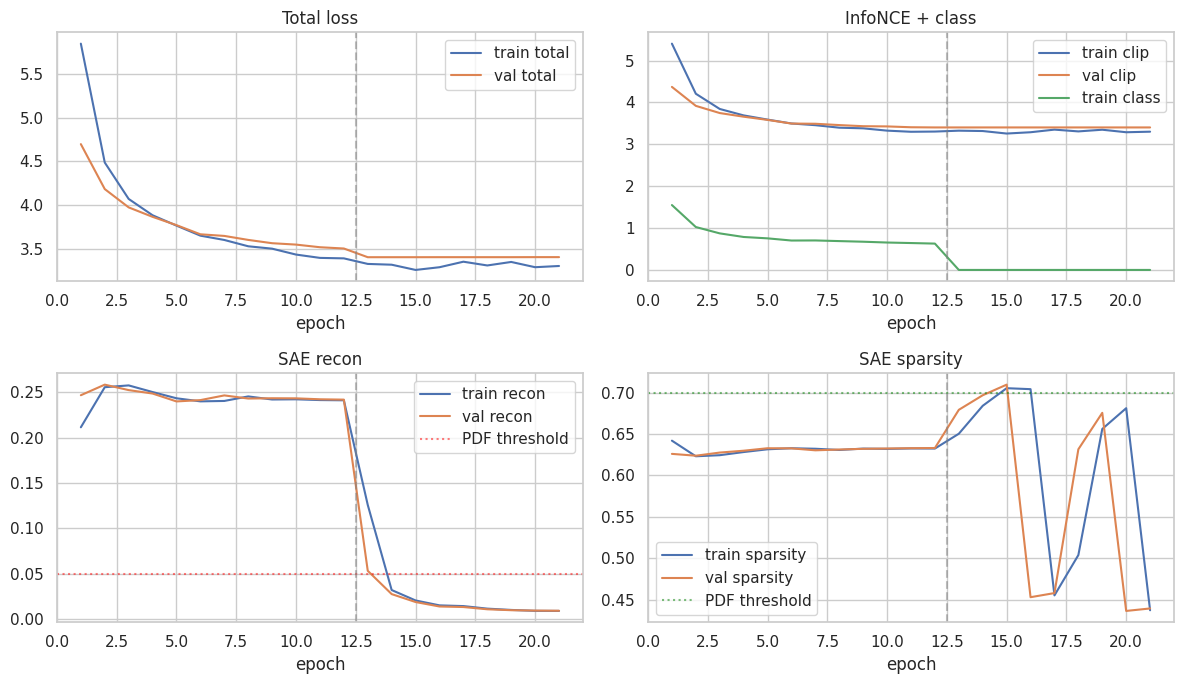

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
if len(history_df):
    axes[0, 0].plot(history_df['epoch'], history_df['train_total'], label='train total')
    axes[0, 0].plot(history_df['epoch'], history_df['val_total'], label='val total')
    axes[0, 0].axvline(PHASE1_EPOCHS + 0.5, ls='--', color='gray', alpha=0.5)
    axes[0, 0].set_title('Total loss'); axes[0, 0].legend(); axes[0, 0].set_xlabel('epoch')

    axes[0, 1].plot(history_df['epoch'], history_df['train_clip'], label='train clip')
    axes[0, 1].plot(history_df['epoch'], history_df['val_clip'], label='val clip')
    axes[0, 1].plot(history_df['epoch'], history_df['train_class'], label='train class')
    axes[0, 1].axvline(PHASE1_EPOCHS + 0.5, ls='--', color='gray', alpha=0.5)
    axes[0, 1].set_title('InfoNCE + class'); axes[0, 1].legend(); axes[0, 1].set_xlabel('epoch')

    axes[1, 0].plot(history_df['epoch'], history_df['train_recon_img'], label='train recon')
    axes[1, 0].plot(history_df['epoch'], history_df['val_recon_img'], label='val recon')
    axes[1, 0].axhline(PDF_THRESHOLDS['recon_visual_max'], ls=':', color='red', alpha=0.5, label='PDF threshold')
    axes[1, 0].axvline(PHASE1_EPOCHS + 0.5, ls='--', color='gray', alpha=0.5)
    axes[1, 0].set_title('SAE recon'); axes[1, 0].legend(); axes[1, 0].set_xlabel('epoch')

    axes[1, 1].plot(history_df['epoch'], history_df['train_sparsity_img'], label='train sparsity')
    axes[1, 1].plot(history_df['epoch'], history_df['val_sparsity_img'], label='val sparsity')
    axes[1, 1].axhline(PDF_THRESHOLDS['sparsity_visual_min'], ls=':', color='green', alpha=0.5, label='PDF threshold')
    axes[1, 1].axvline(PHASE1_EPOCHS + 0.5, ls='--', color='gray', alpha=0.5)
    axes[1, 1].set_title('SAE sparsity'); axes[1, 1].legend(); axes[1, 1].set_xlabel('epoch')

    fig.tight_layout()
    fig.savefig(FIG_DIR / 'training_curves_dual_head.png', dpi=160)
plt.show()

In [28]:
ckpt_path = final_ckpt_path
md5 = hashlib.md5(ckpt_path.read_bytes()).hexdigest()

best_phase1_path = CKPT_DIR / 'best_phase1.pt'
md5_phase1 = hashlib.md5(best_phase1_path.read_bytes()).hexdigest() if best_phase1_path.exists() else None

metrics = {
    'experiment': 'sit2_7_clip_sae_1500tiles',
    'pdf_literal': False,
    'pdf_pragmatic_defendible': True,
    'dual_head_architecture': True,
    'dual_phase_checkpointing': True,
    'aux_class_loss': True,
    'no_s5p_numeric_input': True,
    'no_raw_s5p_values_in_text': True,
    'tiles_per_class': TILES_PER_CLASS,
    'n_tiles_total': N_TILES_TOTAL,
    'pdf_min_tiles_compliance': N_TILES_TOTAL >= 1000,
    'captions_per_image': 5,
    'caption_language': 'English',
    'multi_caption_recall': True,
    'effective_batch_size': BATCH_SIZE * GRAD_ACCUM_STEPS,
    'split': '70/15/15 stratified',
    'normalization': 'train only',
    'alpha_sae_max': ALPHA_SAE,
    'beta_class_init': BETA_CLASS_INIT,
    'beta_class_floor': BETA_CLASS_FLOOR,
    'min_unique_caption_ratio': MIN_UNIQUE_CAPTION_RATIO,
    'lambda_l1': LAMBDA_L1,
    'sae_dim': SAE_DIM,
    'proj_dim': PROJ_DIM,
    'phase1_epochs': PHASE1_EPOCHS,
    'phase2_epochs': PHASE2_EPOCHS,
    'per_class_per_batch': PER_CLASS_PER_BATCH,
    'best_epoch_phase1': int(best_epoch_phase1),
    'best_val_clip_phase1': float(best_val_phase1),
    'best_epoch_phase2': int(best_epoch_phase2),
    'best_sae_score_phase2': float(best_sae_score),
    'final_checkpoint_phase': int(best_ckpt['phase']),
    'final_checkpoint_epoch': int(best_ckpt['epoch']),
    'retrieval_val': retrieval_val,
    'retrieval_test': retrieval_test,
    'sae_aux_test': test_emb['aux'],
    'sanity_test': {
        'class_prototype_acc': float(cls_acc_test),
        'knn_class_acc': float(knn_test),
        'alignment_cosine_mean': float(align_cos),
    },
    'pdf_thresholds': PDF_THRESHOLDS,
    'success_pdf_end_to_end': success_pdf,
    'sae_post_hoc': sae_post_hoc_metrics,
    'sae_post_hoc_md5': sae_post_hoc_md5,
    'text_stats': text_stats,
    'checkpoint_md5': md5,
    'checkpoint_md5_phase1': md5_phase1,
}

with open(OUT_DIR / 'metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)
with open(OUT_DIR / 'checkpoint.md5', 'w') as f:
    f.write(md5)
np.savez_compressed(
    EMB_DIR / 'test_embeddings_1500tiles.npz',
    image_dense=test_emb['image_dense'].numpy(),
    image_base=test_emb['image_base'].numpy(),
    text_dense=test_emb['text_dense'].numpy(),
    caption_owner=test_emb['caption_owner'].numpy(),
    label=test_emb['label'],
    index=test_emb['index'],
)
print(json.dumps(metrics, indent=2))

{
  "experiment": "sit2_7_clip_sae_1500tiles",
  "pdf_literal": false,
  "pdf_pragmatic_defendible": true,
  "dual_head_architecture": true,
  "dual_phase_checkpointing": true,
  "aux_class_loss": true,
  "no_s5p_numeric_input": true,
  "no_raw_s5p_values_in_text": true,
  "tiles_per_class": 300,
  "n_tiles_total": 1500,
  "pdf_min_tiles_compliance": true,
  "captions_per_image": 5,
  "caption_language": "English",
  "multi_caption_recall": true,
  "effective_batch_size": 120,
  "split": "70/15/15 stratified",
  "normalization": "train only",
  "alpha_sae_max": 0.05,
  "beta_class_init": 0.3,
  "beta_class_floor": 0.05,
  "min_unique_caption_ratio": 0.85,
  "lambda_l1": 0.03,
  "sae_dim": 1024,
  "proj_dim": 256,
  "phase1_epochs": 12,
  "phase2_epochs": 10,
  "per_class_per_batch": 12,
  "best_epoch_phase1": 12,
  "best_val_clip_phase1": 3.40282279253006,
  "best_epoch_phase2": 15,
  "best_sae_score_phase2": 0.3089804071933031,
  "final_checkpoint_phase": 2,
  "final_checkpoint_epoch"